In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import community as community_louvain
from scipy.stats import zscore
import scipy.sparse as sp
import pynetcor as pnc
from pynetcor.cor import cor_topk
from pynetcor.cor import cortest, chunked_cortest
import multiprocessing
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
import plotly.graph_objects as go

In [2]:
# ------------------------------
# Set dataPaths
# ------------------------------
gse_expressionPath = "C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/00databases/01GeneMatrix_gse102556-08052025.csv.gz"
uth_expressionPath = "C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/00databases/01GeneMatrix_uthealth-08182025.csv.gz"
vaa_expressionPath = 'C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/00databases/01transcriptome/00data/00vabb_genecounts-08152025.csv.gz'

In [3]:
# ------------------------------
# Load Datasets
# ------------------------------
gse = pd.read_csv(gse_expressionPath, index_col = 0)
uth = pd.read_csv(uth_expressionPath, index_col = 0)
vaa = pd.read_csv(vaa_expressionPath, index_col = 0)

print("UTHealth data:", gse.shape)
print("GSE data:", uth.shape)
print("VABB data:", vaa.shape)

UTHealth data: (57773, 96)
GSE data: (25438, 89)
VABB data: (60605, 551)


In [4]:
# ------------------------------
# Add the filter for the genes in the Clocks
# ------------------------------
clockgenesP = 'C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/02results/08functional/03merged_genes-08212025.csv'
clockgenes = pd.read_csv(clockgenesP)

In [5]:
# ------------------------------
# Filter genes in clocks
# ------------------------------
# get unique Ensembl IDs from the annotation dataframe
ensembl_keep = clockgenes['Ensembl'].unique()
# filter expression matrices
uth_filtered = uth.loc[uth.index.intersection(ensembl_keep)]
gse_filtered = gse.loc[gse.index.intersection(ensembl_keep)]
vaa_filtered = vaa.loc[vaa.index.intersection(ensembl_keep)]

print("UTHealth data:", uth_filtered.shape)
print("GSE data:", gse_filtered.shape)
print("VABB data:", vaa_filtered.shape)

UTHealth data: (18261, 89)
GSE data: (17754, 96)
VABB data: (18103, 551)


In [6]:
# ------------------------------
# Find common genes across all datasets
# ------------------------------
common_genes = set(uth_filtered.index) & set(gse_filtered.index) & set(vaa_filtered.index)
print("Genes in all datasets:", len(common_genes))
uth_final = uth_filtered.loc[uth_filtered.index.intersection(common_genes)]
gse_final = gse_filtered.loc[gse_filtered.index.intersection(common_genes)]
vaa_final = vaa_filtered.loc[vaa_filtered.index.intersection(common_genes)]

print("UTHealth:", uth_final.shape)
print("GSE:", gse_final.shape)
print("VABB:", vaa_final.shape)

Genes in all datasets: 17663
UTHealth: (17663, 89)
GSE: (17663, 96)
VABB: (17663, 551)


In [7]:
# ------------------------------
# Define a function to z-score the genes
# ------------------------------
def zscore(df):
    """Row-wise z-score, skipping genes with zero variance."""
    df = df.copy()
    row_std = df.std(axis=1)
    keep = row_std > 0  # avoid division by zero
    df = df.loc[keep]
    return ((df.T - df.mean(axis=1)) / df.std(axis=1)).T

In [8]:
# ------------------------------
# Z-score the expression matrix
# ------------------------------
uth_z = zscore(uth_final)
gse_z = zscore(gse_final)
vaa_z = zscore(vaa_final)
print("UTHealth:", uth_z.shape)
print("GSE:", gse_z.shape)
print("VABB:", vaa_z.shape)

# ------------------------------
# Find common genes across all datasets
# ------------------------------
common_genes = set(uth_z.index) & set(gse_z.index) & set(vaa_z.index)
print("Genes in all datasets:", len(common_genes))
uth_z = uth_z.loc[uth_z.index.intersection(common_genes)]
gse_z = gse_z.loc[gse_z.index.intersection(common_genes)]
vaa_z = vaa_z.loc[vaa_z.index.intersection(common_genes)]
print("UTHealth:", uth_z.shape)
print("GSE:", gse_z.shape)
print("VABB:", vaa_z.shape)

UTHealth: (17578, 89)
GSE: (17405, 96)
VABB: (17515, 551)
Genes in all datasets: 17308
UTHealth: (17308, 89)
GSE: (17308, 96)
VABB: (17308, 551)


In [9]:
# ---------------------------------------------
# Compute the correlation network
# ---------------------------------------------
n_threads = max(1, multiprocessing.cpu_count() - 1)
uth_z_T = uth_z.T
corr_results = cortest(uth_z_T, threads=n_threads)
# Build edge DataFrame
edges1 = pd.DataFrame({
    "Gene1": [uth_z_T.columns[int(i)] for i in corr_results[:, 0]],
    "Gene2": [uth_z_T.columns[int(i)] for i in corr_results[:, 1]],
    "Correlation": corr_results[:, 2],
    "Pval": corr_results[:, 3]
})
edges1

,Gene1,Gene2,Correlation,Pval
0,ENSG00000177757,ENSG00000228794,-0.236670,6.165874e-219
1,ENSG00000177757,ENSG00000223764,-0.085296,2.558371e-29
2,ENSG00000177757,ENSG00000187634,-0.028757,1.544796e-04
3,ENSG00000177757,ENSG00000188976,-0.058574,1.237544e-14
4,ENSG00000177757,ENSG00000187961,-0.222623,2.588043e-193
...,...,...,...,...
3911,ENSG00000116251,ENSG00000116237,-0.138926,2.507880e-75
3912,ENSG00000116251,ENSG00000158292,0.060849,1.110223e-15
3913,ENSG00000158286,ENSG00000116237,0.170998,0.000000e+00
3914,ENSG00000158286,ENSG00000158292,0.379816,0.000000e+00


In [10]:
# ---------------------------------------------
# Compute the correlation network
# ---------------------------------------------
n_threads = max(1, multiprocessing.cpu_count() - 1)
gse_z_T = gse_z.T
corr_results2 = cortest(gse_z_T, threads=n_threads)
# Build edge DataFrame
edges2 = pd.DataFrame({
    "Gene1": [gse_z_T.columns[int(i)] for i in corr_results2[:, 0]],
    "Gene2": [gse_z_T.columns[int(i)] for i in corr_results2[:, 1]],
    "Correlation": corr_results2[:, 2],
    "Pval": corr_results2[:, 3]
})
edges2

,Gene1,Gene2,Correlation,Pval
0,ENSG00000000003,ENSG00000000005,0.115134,0.000000e+00
1,ENSG00000000003,ENSG00000000419,0.222741,0.000000e+00
2,ENSG00000000003,ENSG00000000457,-0.047901,2.880644e-10
3,ENSG00000000003,ENSG00000000938,0.234663,0.000000e+00
4,ENSG00000000003,ENSG00000000971,-0.443652,0.000000e+00
...,...,...,...,...
4555,ENSG00000005471,ENSG00000005486,0.256777,0.000000e+00
4556,ENSG00000005471,ENSG00000005513,0.158097,0.000000e+00
4557,ENSG00000005483,ENSG00000005486,0.171412,0.000000e+00
4558,ENSG00000005483,ENSG00000005513,0.095719,0.000000e+00


In [11]:
# ---------------------------------------------
# Compute the correlation network
# ---------------------------------------------
n_threads = max(1, multiprocessing.cpu_count() - 1)
vaa_z_T = vaa_z.T
corr_results3 = cortest(vaa_z_T, threads=n_threads)
# Build edge DataFrame
edges3 = pd.DataFrame({
    "Gene1": [vaa_z_T.columns[int(i)] for i in corr_results3[:, 0]],
    "Gene2": [vaa_z_T.columns[int(i)] for i in corr_results3[:, 1]],
    "Correlation": corr_results3[:, 2],
    "Pval": corr_results3[:, 3]
})
edges3

,Gene1,Gene2,Correlation,Pval
0,ENSG00000186827,ENSG00000186891,0.495306,2.200000e-16
1,ENSG00000186827,ENSG00000160072,0.309425,2.200000e-16
2,ENSG00000186827,ENSG00000041988,0.387642,2.200000e-16
3,ENSG00000186827,ENSG00000228037,0.576546,2.200000e-16
4,ENSG00000186827,ENSG00000142611,0.282103,2.200000e-16
...,...,...,...,...
151520,ENSG00000143315,ENSG00000143185,-0.222054,2.200000e-16
151521,ENSG00000143315,ENSG00000007933,-0.219424,2.200000e-16
151522,ENSG00000116199,ENSG00000143185,0.070012,2.200000e-16
151523,ENSG00000116199,ENSG00000007933,0.008996,2.366406e-01


In [12]:
# Add source column to each edge DataFrame
edges1['Source'] = 'UTHealth'
edges2['Source'] = 'GSE102556'
edges3['Source'] = 'VABB'

# Combine all into one DataFrame
all_edges = pd.concat([edges1, edges2, edges3], ignore_index=True)

# Optional: sort by Gene1, Gene2 for reproducibility
all_edges = all_edges.sort_values(['Gene1', 'Gene2', 'Source']).reset_index(drop=True)

# Check
print(all_edges.head())
all_edges.to_csv("C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/02results/08functional/00alledges_clockgenes-09012025.csv",
                 index=False)

             Gene1            Gene2  Correlation          Pval     Source
0  ENSG00000000003  ENSG00000000005     0.115134  0.000000e+00  GSE102556
1  ENSG00000000003  ENSG00000000419     0.222741  0.000000e+00  GSE102556
2  ENSG00000000003  ENSG00000000457    -0.047901  2.880644e-10  GSE102556
3  ENSG00000000003  ENSG00000000938     0.234663  0.000000e+00  GSE102556
4  ENSG00000000003  ENSG00000000971    -0.443652  0.000000e+00  GSE102556


In [13]:
# ---------------------------
# Strict consensus network
# ---------------------------
def consensus_edges(edge_dfs, min_agreement=2, corr_threshold=0.2):
    """
    edge_dfs: list of DataFrames with columns ['Gene1','Gene2','Correlation']
    min_agreement: minimum number of datasets where edge must appear
    corr_threshold: minimum absolute correlation to consider
    """
    # Keep edges above correlation threshold
    filtered_edges = []
    for df in edge_dfs:
        filtered = df[abs(df['Correlation']) >= corr_threshold].copy()
        # Make a consistent identifier for edge (unordered)
        filtered['edge'] = filtered.apply(lambda x: tuple(sorted([x['Gene1'], x['Gene2']])), axis=1)
        filtered_edges.append(filtered)
    
    # Count edge occurrences
    all_edges = pd.concat(filtered_edges)
    edge_counts = all_edges['edge'].value_counts()
    
    # Keep edges appearing in at least min_agreement datasets
    consensus_edges_list = edge_counts[edge_counts >= min_agreement].index.tolist()
    
    # Build consensus DataFrame with average correlation
    consensus_rows = []
    for edge in consensus_edges_list:
        corrs = []
        for df in filtered_edges:
            mask = df['edge'] == edge
            if mask.any():
                corrs.append(df.loc[mask, 'Correlation'].values[0])
        avg_corr = np.mean(corrs)
        consensus_rows.append((edge[0], edge[1], avg_corr))
    
    consensus_df = pd.DataFrame(consensus_rows, columns=['Gene1','Gene2','AvgCorrelation'])
    return consensus_df

In [14]:
# ---------------------------
# Computation
# ---------------------------
consensus_df = consensus_edges([edges1, edges2, edges3], min_agreement=2, corr_threshold=0.2)
print("Consensus edges:", consensus_df.shape[0])
consensus_df

Consensus edges: 154


,Gene1,Gene2,AvgCorrelation
0,ENSG00000149527,ENSG00000196581,0.015996
1,ENSG00000162585,ENSG00000162591,0.036107
2,ENSG00000157881,ENSG00000162571,0.531214
3,ENSG00000157881,ENSG00000162585,0.312139
4,ENSG00000162571,ENSG00000228037,0.342388
...,...,...,...
149,ENSG00000162571,ENSG00000169972,0.267330
150,ENSG00000158292,ENSG00000162592,0.358600
151,ENSG00000160072,ENSG00000224051,0.300991
152,ENSG00000116251,ENSG00000149527,0.297612


In [15]:
# ---------------------------
# RWR-based consensus network
# ---------------------------
def rwr_consensus(edge_dfs, r_treshold=0.2, alpha=0.7, max_iter=100, tol=1e-6):
    """
    Build networks for each edge DataFrame, run RWR, and combine node scores.
    Returns: dict of node -> consensus score
    """
    node_scores = {}
    graphs = []
    
    # Build graphs
    for df in edge_dfs:
        G = nx.Graph()
        edges = [(row['Gene1'], row['Gene2'], row['Correlation']) 
                 for _, row in df.iterrows() if abs(row['Correlation']) >= r_treshold]
        G.add_weighted_edges_from(edges)
        graphs.append(G)
    
    # Random Walk with Restart
    for G in graphs:
        nodes = sorted(G.nodes())
        A = nx.to_numpy_array(G, nodelist=nodes, weight='weight')
        # Normalize adjacency
        P = A / A.sum(axis=1, keepdims=True)
        r = np.ones(len(nodes)) / len(nodes)  # initial probability
        r_prev = np.zeros(len(nodes))
        for _ in range(max_iter):
            r_new = alpha * P.T @ r + (1 - alpha) * r
            if np.linalg.norm(r_new - r_prev, 1) < tol:
                break
            r_prev = r_new
        # Accumulate scores
        for i, node in enumerate(nodes):
            node_scores[node] = node_scores.get(node, 0) + r_new[i]
    
    # Average scores across networks
    for node in node_scores:
        node_scores[node] /= len(graphs)
    
    return node_scores

In [16]:
# ---------------------------
# Example usage
# ---------------------------
rwr_scores = rwr_consensus([edges1, edges2, edges3], alpha=0.7)
# Convert all RWR scores to DataFrame
all_genes_df = pd.DataFrame(rwr_scores.items(), columns=['Gene', 'RWR_score'])
# Sort by RWR_score descending
all_genes_df = all_genes_df.sort_values('RWR_score', ascending=False).reset_index(drop=True)
print(all_genes_df.head(20))

               Gene  RWR_score
0   ENSG00000004939   0.097975
1   ENSG00000236423   0.096322
2   ENSG00000127054   0.092133
3   ENSG00000157873   0.088254
4   ENSG00000130764   0.086576
5   ENSG00000116213   0.085804
6   ENSG00000131584   0.085149
7   ENSG00000162592   0.080900
8   ENSG00000004838   0.079476
9   ENSG00000169962   0.063925
10  ENSG00000004766   0.059982
11  ENSG00000149527   0.059837
12  ENSG00000005249   0.058221
13  ENSG00000069424   0.056293
14  ENSG00000242485   0.053373
15  ENSG00000005187   0.050445
16  ENSG00000237330   0.047456
17  ENSG00000186891   0.046720
18  ENSG00000228794   0.046618
19  ENSG00000078808   0.044451


In [17]:
# ---------------------------
# Compute thresholds (95th percentile for RWR score)
# ---------------------------
# Compute 95th percentile of RWR_score
threshold_95 = np.percentile(all_genes_df['RWR_score'], 95)
# Create a new column labeling Above/Below 95th percentile
all_genes_df['RWR_score_95th'] = np.where(all_genes_df['RWR_score'] >= threshold_95, "Above", "Below")
# Optional: filter only top genes
top_genes_95th = all_genes_df[all_genes_df['RWR_score_95th'] == "Above"]
print(top_genes_95th)

               Gene  RWR_score RWR_score_95th
0   ENSG00000004939   0.097975          Above
1   ENSG00000236423   0.096322          Above
2   ENSG00000127054   0.092133          Above
3   ENSG00000157873   0.088254          Above
4   ENSG00000130764   0.086576          Above
5   ENSG00000116213   0.085804          Above
6   ENSG00000131584   0.085149          Above
7   ENSG00000162592   0.080900          Above
8   ENSG00000004838   0.079476          Above
9   ENSG00000169962   0.063925          Above
10  ENSG00000004766   0.059982          Above
11  ENSG00000149527   0.059837          Above
12  ENSG00000005249   0.058221          Above
13  ENSG00000069424   0.056293          Above
14  ENSG00000242485   0.053373          Above
15  ENSG00000005187   0.050445          Above
16  ENSG00000237330   0.047456          Above
17  ENSG00000186891   0.046720          Above
18  ENSG00000228794   0.046618          Above
19  ENSG00000078808   0.044451          Above
20  ENSG00000215915   0.043049    

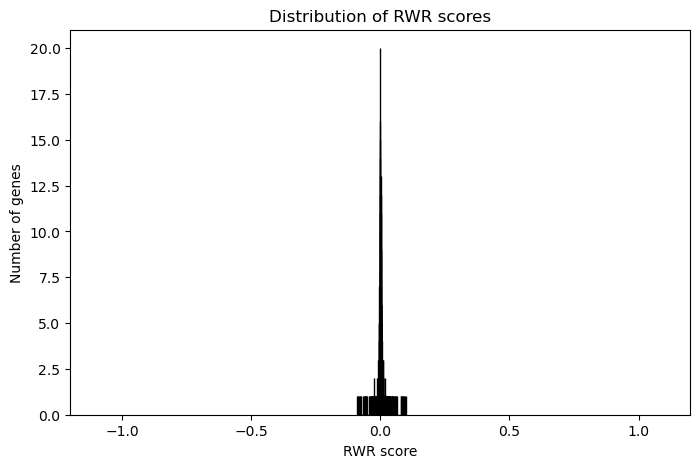

In [18]:
# Assuming `grin_scores` and `all_genes_df` are your DataFrames
# all_genes_df: DataFrame with column 'RWR_score'

# Histogram of RWR scores
plt.figure(figsize=(8, 5))
plt.hist(all_genes_df['RWR_score'], bins=2000, color='salmon', edgecolor='black')
plt.title("Distribution of RWR scores")
plt.xlabel("RWR score")
plt.ylabel("Number of genes")
plt.xlim(-1.2,1.2)
plt.show()

In [19]:
#----------------------------
# Saving RWR scores
#----------------------------
all_genes_df.to_csv("C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/02results/08functional/00RWR_singlelayer_clockgenes-08222025.csv",
                     index=False)
top_genes_95th.to_csv("C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/02results/08functional/00RWR_singlelayer_95th_clockgenes-08222025.csv",
                     index=False)

In [20]:
# ---------------------------
# Build 3D layer RWR
# ---------------------------
def _make_layer_matrix(genes, edges_df, corr_threshold=0.2, use_abs=True, directed=False):
    """
    Build a sparse adjacency for a single layer.
    genes: list of all genes (union across layers, consistent order)
    edges_df: columns ['Gene1','Gene2','Correlation']
    """
    idx = {g:i for i,g in enumerate(genes)}
    rows, cols, data = [], [], []

    # filter by threshold
    df = edges_df.loc[edges_df['Correlation'].abs() >= corr_threshold].copy()

    for _, row in df.iterrows():
        g1, g2 = row['Gene1'], row['Gene2']
        if g1 not in idx or g2 not in idx:
            continue
        w = abs(row['Correlation']) if use_abs else row['Correlation']
        if w <= 0:
            continue  # RWR needs nonnegative weights
        i, j = idx[g1], idx[g2]
        rows.append(i); cols.append(j); data.append(w)
        if not directed:
            rows.append(j); cols.append(i); data.append(w)

    n = len(genes)
    if len(data) == 0:
        # empty layer
        return sp.csr_matrix((n, n), dtype=float)
    return sp.csr_matrix((data, (rows, cols)), shape=(n, n), dtype=float)


def multiplex_rwr(
    edge_dfs,
    corr_threshold=0.2,
    use_abs=True,
    directed=False,
    omega=0.5,
    alpha=0.7,
    max_iter=200,
    tol=1e-9,
    seeds=None,
    return_per_layer=False
):
    """
    Multi-layer (multiplex) RWR over 3 (or more) correlation networks.

    Parameters
    ----------
    edge_dfs : list[pd.DataFrame]
        Each with ['Gene1','Gene2','Correlation'].
    corr_threshold : float
        Keep edges with |corr| >= threshold.
    use_abs : bool
        Use |corr| so weights are >= 0 (recommended for RWR).
    directed : bool
        If True, build directed layers; otherwise undirected.
    omega : float
        Inter-layer coupling between the same gene across layers.
    alpha : float
        RWR “walk” probability (restart prob = 1 - alpha).
    max_iter : int
        Max RWR iterations.
    tol : float
        L1 convergence tolerance.
    seeds : list[str] or None
        Optional seed genes; if None, uniform over all nodes in all layers.
    return_per_layer : bool
        If True, also return per-layer scores.

    Returns
    -------
    scores_df : pd.DataFrame
        Columns: ['Gene','RWR_multiplex'] (+ optional per-layer columns)
    """

    # ---- collect master gene list (union across layers) ----
    genes_sets = []
    for df in edge_dfs:
        genes_sets.append(set(pd.concat([df['Gene1'], df['Gene2']]).unique()))
    genes = sorted(set().union(*genes_sets))
    n = len(genes)
    L = len(edge_dfs)
    if n == 0:
        return pd.DataFrame(columns=['Gene','RWR_multiplex'])

    # ---- build each layer adjacency (sparse) ----
    layer_blocks = [
        _make_layer_matrix(genes, df, corr_threshold=corr_threshold, use_abs=use_abs, directed=directed)
        for df in edge_dfs
    ]

    # ---- block-diagonal intra-layer adjacency ----
    A_intra = sp.block_diag(layer_blocks, format='csr')

    # ---- inter-layer coupling: connect same node across layers with weight omega ----
    # Create LxL matrix with 0 on diagonal and omega off-diagonals
    C = np.full((L, L), omega, dtype=float)
    np.fill_diagonal(C, 0.0)
    # Kronecker with Identity(n): size (L*n) x (L*n)
    A_inter = sp.kron(sp.csr_matrix(C), sp.identity(n, format='csr', dtype=float), format='csr')

    # ---- supra adjacency ----
    A = A_intra + A_inter  # (L*n) x (L*n) sparse

    # ---- row-normalize to get transition matrix P ----
    row_sums = np.array(A.sum(axis=1)).ravel()
    # handle zero rows (isolated): put self-loop to keep stochastic
    zero_rows = (row_sums == 0)
    if zero_rows.any():
        A = A + sp.diags(zero_rows.astype(float))  # add 1.0 on diagonal where needed
        row_sums = np.array(A.sum(axis=1)).ravel()

    inv_row = 1.0 / row_sums
    P = sp.diags(inv_row) @ A  # row-stochastic

    # ---- restart vector v ----
    m = L * n
    v = np.zeros(m, dtype=float)
    if seeds is None or len(seeds) == 0:
        v[:] = 1.0 / m
    else:
        gene_to_idx = {g:i for i,g in enumerate(genes)}
        seed_positions = []
        for g in seeds:
            if g in gene_to_idx:
                gi = gene_to_idx[g]
                # add this gene in every layer position
                for ell in range(L):
                    seed_positions.append(ell*n + gi)
        if len(seed_positions) == 0:
            v[:] = 1.0 / m
        else:
            v[seed_positions] = 1.0 / len(seed_positions)

    # ---- RWR iterations over supra graph ----
    r = v.copy()
    for _ in range(max_iter):
        r_new = alpha * (P.T @ r) + (1 - alpha) * v
        if np.linalg.norm(r_new - r, 1) < tol:
            r = r_new
            break
        r = r_new

    # ---- aggregate layer scores back to per-gene ----
    # reshape to (L, n), average across layers
    R = r.reshape(L, n)
    cons = R.mean(axis=0)

    out = {'Gene': genes, 'RWR_multiplex': cons}
    if return_per_layer:
        for ell in range(L):
            out[f'RWR_layer{ell+1}'] = R[ell, :]
    scores_df = pd.DataFrame(out).sort_values('RWR_multiplex', ascending=False).reset_index(drop=True)
    return scores_df

In [21]:
# edges1, edges2, edges3 already exist with ['Gene1','Gene2','Correlation']
scores_multiplex = multiplex_rwr(
    [edges1, edges2, edges3],
    corr_threshold=0.2,   # keep reasonably strong edges
    omega=0.5,            # cross-layer tie strength (0.2–1.0 is typical)
    alpha=0.7,            # walk prob; 0.6–0.9 commonly used
    seeds=None,           # or a list like ['ENSG000001...', 'ENSG00000...']
    return_per_layer=True # also get layer-wise scores
)
# Suppose scores_multiplex is a DataFrame with columns: 'Gene', 'RWR_score', ...
# Compute the 95th percentile
threshold_95 = scores_multiplex['RWR_multiplex'].quantile(0.95)
# Add a new column indicating if the gene is above the 95th percentile
scores_multiplex['Top_5_percent'] = scores_multiplex['RWR_multiplex'] > threshold_95
# Optional: check results
print(scores_multiplex.head(20))

               Gene  RWR_multiplex  RWR_layer1  RWR_layer2  RWR_layer3  \
0   ENSG00000186827       0.000916    0.001062    0.000164    0.001521   
1   ENSG00000162571       0.000913    0.001121    0.000163    0.001455   
2   ENSG00000078900       0.000813    0.001170    0.000164    0.001106   
3   ENSG00000142655       0.000795    0.000229    0.000229    0.001928   
4   ENSG00000228037       0.000787    0.000699    0.000165    0.001496   
5   ENSG00000069424       0.000780    0.000900    0.000164    0.001276   
6   ENSG00000116157       0.000777    0.000229    0.000229    0.001873   
7   ENSG00000162592       0.000769    0.000941    0.000163    0.001203   
8   ENSG00000107404       0.000760    0.000781    0.000164    0.001334   
9   ENSG00000187513       0.000750    0.000229    0.000229    0.001791   
10  ENSG00000215704       0.000735    0.000229    0.000229    0.001747   
11  ENSG00000142661       0.000730    0.000229    0.000229    0.001731   
12  ENSG00000117528       0.000728    

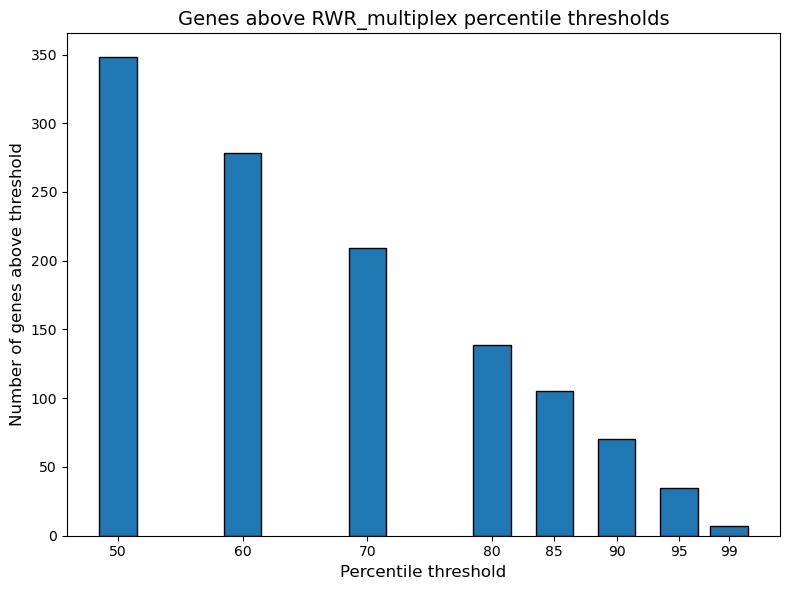

In [22]:
# Define thresholds
percentiles = [0.50, 0.60, 0.70, 0.80, 0.85, 0.90, 0.95, 0.99]
# Compute threshold values
threshold_values = {int(p*100): scores_multiplex['RWR_multiplex'].quantile(p) for p in percentiles}
# Count how many genes are above each threshold
counts = {perc: (scores_multiplex['RWR_multiplex'] > thr).sum() 
          for perc, thr in threshold_values.items()}
# Convert to sorted lists for plotting
x = list(counts.keys())
y = list(counts.values())
# Plot
plt.figure(figsize=(8,6))
plt.bar(x, y, width=3, edgecolor='black')
plt.xlabel("Percentile threshold", fontsize=12)
plt.ylabel("Number of genes above threshold", fontsize=12)
plt.title("Genes above RWR_multiplex percentile thresholds", fontsize=14)
plt.xticks(x)
plt.tight_layout()
plt.show()

In [23]:
#----------------------------
# Saving
#----------------------------
# Merge annotation into scores_multiplex
scores_multiplex_annotated = scores_multiplex.merge(
    clockgenes,
    left_on='Gene',   # column in scores_multiplex
    right_on='Ensembl',  # column in annotation
)

# Optional: drop the redundant 'Ensembl' column
scores_multiplex_annotated = scores_multiplex_annotated.drop(columns=['Ensembl'])
scores_multiplex_annotated_nodup = scores_multiplex_annotated.drop_duplicates(
    subset=['Gene'],  # column(s) to check for duplicates
    keep='first'      # keep the first occurrence
)

#----------------------------
# Saving
#----------------------------
scores_multiplex_annotated_nodup.to_csv('C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/02results/08functional/00RWR_multiplex_clockgenes-08222025.csv',
                        index=False)

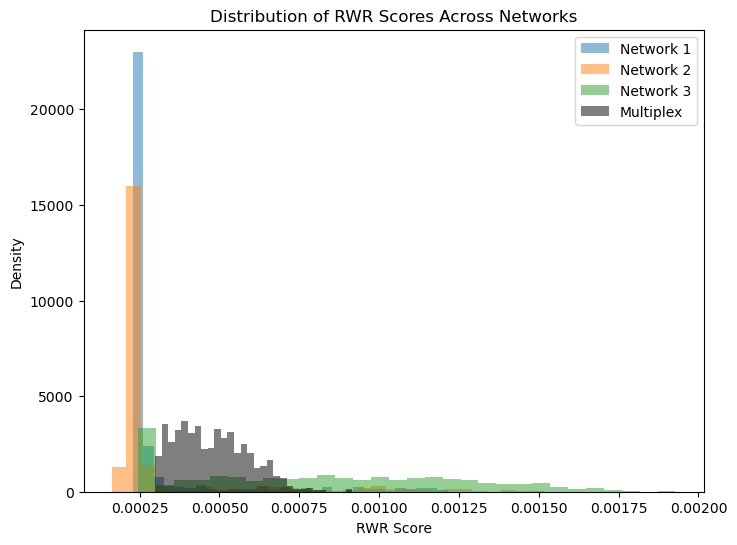

In [24]:
plt.figure(figsize=(8,6))
# Overlay histograms for each network’s RWR scores
plt.hist(scores_multiplex['RWR_layer1'], bins=30, alpha=0.5, label='Network 1', density=True)
plt.hist(scores_multiplex['RWR_layer2'], bins=30, alpha=0.5, label='Network 2', density=True)
plt.hist(scores_multiplex['RWR_layer3'], bins=30, alpha=0.5, label='Network 3', density=True)

# Optional: also plot consensus distribution
plt.hist(scores_multiplex['RWR_multiplex'], bins=30, alpha=0.5, label='Multiplex', density=True, color='black')

plt.xlabel("RWR Score")
plt.ylabel("Density")
plt.title("Distribution of RWR Scores Across Networks")
plt.legend()
plt.show()

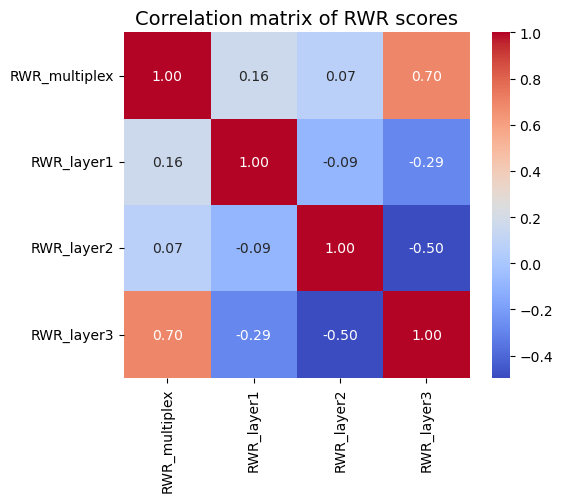

               RWR_multiplex  RWR_layer1  RWR_layer2  RWR_layer3
RWR_multiplex       1.000000    0.161553     0.07274    0.695401
RWR_layer1          0.161553    1.000000    -0.09228   -0.287083
RWR_layer2          0.072740   -0.092280     1.00000   -0.495660
RWR_layer3          0.695401   -0.287083    -0.49566    1.000000


In [25]:
# Compute correlation matrix
corr_matrix = scores_multiplex[['RWR_multiplex','RWR_layer1','RWR_layer2','RWR_layer3']].corr()
# Plot heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", square=True, cbar=True)
plt.title("Correlation matrix of RWR scores", fontsize=14)
plt.tight_layout()
plt.show()
# Also print numerical matrix
print(corr_matrix)

NameError: name 'color_map' is not defined

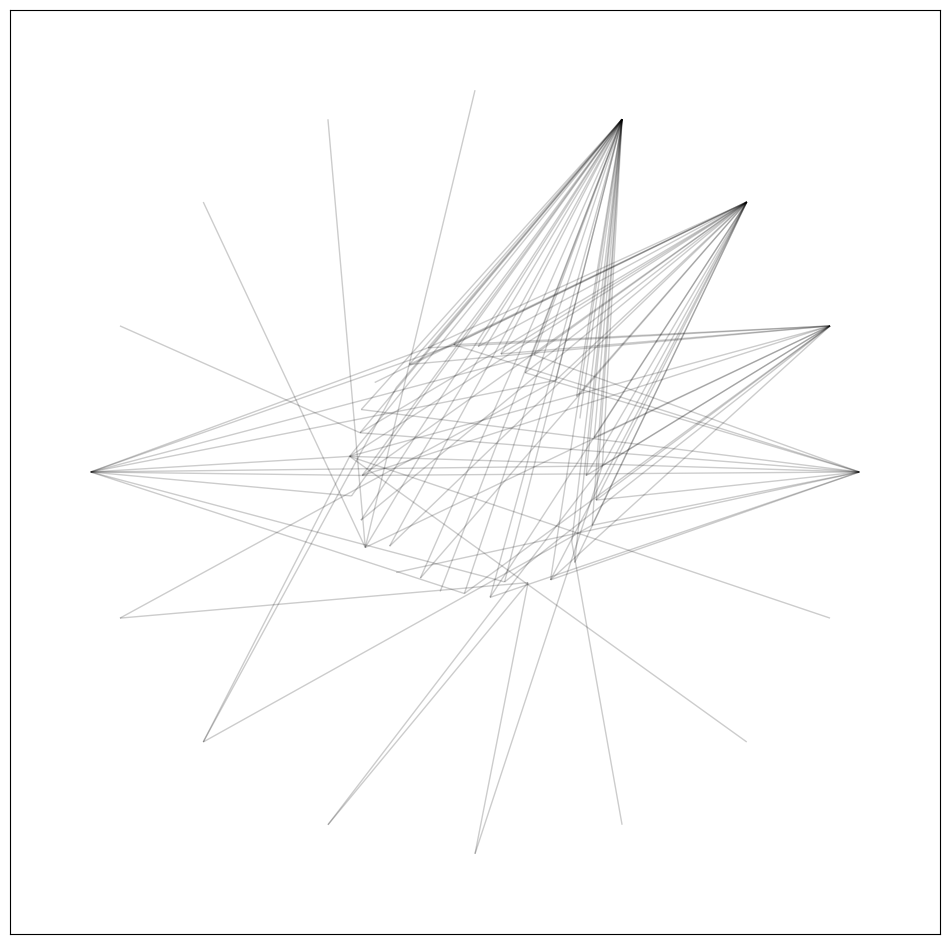

In [26]:
# Optionally filter to top 5% genes (to avoid huge network)
df_plot = scores_multiplex_annotated[scores_multiplex_annotated["Top_5_percent"]]

# Create a network: Gene ↔ Clock
G = nx.Graph()

for _, row in df_plot.iterrows():
    gene = row["Gene"]
    clock = row["Clock"]
    score = row["RWR_multiplex"]

    # Add gene node (size scaled by RWR_multiplex)
    G.add_node(gene, 
               size=score * 50000,   # adjust scale for visibility
               node_type="Gene", 
               clock=clock)

    # Add clock node (fixed size, categorical color)
    G.add_node(clock, 
               size=3000, 
               node_type="Clock")

    # Add edge between gene and clock
    G.add_edge(gene, clock)

# Separate nodes
clocks = [n for n, d in G.nodes(data=True) if d["node_type"] == "Clock"]
genes  = [n for n, d in G.nodes(data=True) if d["node_type"] == "Gene"]

# --- Layout ---
pos = {}

# Place clocks evenly spaced on a big circle (outer ring)
angle_step = 2 * np.pi / len(clocks)
radius_outer = 3.0
for i, clock in enumerate(clocks):
    angle = i * angle_step
    pos[clock] = (radius_outer * np.cos(angle), radius_outer * np.sin(angle))

# Place genes with a force-directed layout (smaller radius, inner cloud)
# Start from spring_layout, then shrink positions
inner_pos = nx.spring_layout(G.subgraph(genes), scale=1.0, center=(0, 0))
for gene, p in inner_pos.items():
    pos[gene] = (p[0] * 1.0, p[1] * 1.0)

# --- Draw ---
plt.figure(figsize=(12, 12))
nx.draw_networkx_edges(G, pos, alpha=0.2)

nx.draw_networkx_nodes(
    G, pos,
    nodelist=genes,
    node_color=[color_map[G.nodes[g]["clock"]] for g in genes],
    node_size=[G.nodes[g]["size"] for g in genes],
    alpha=0.8
)
nx.draw_networkx_nodes(
    G, pos,
    nodelist=clocks,
    node_color="black",
    node_size=[G.nodes[c]["size"] for c in clocks],
    alpha=0.9
)

# Labels for clocks only
nx.draw_networkx_labels(
    G, pos,
    labels={c: c for c in clocks},
    font_size=12,
    font_color="white",
    font_weight="bold"
)

plt.title("Gene–Clock Network (clocks = outer ring, genes = middle)", fontsize=16)
plt.axis("off")
plt.show()